In [2]:
import xarray as xr
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from matplotlib import pyplot as plt

In [3]:
# check what the scale factor is between max daily 8-hour average ozone and daily average

In [1]:
ds = xr.open_mfdataset("era5_hourly/era5_ozone_1000hpa_hourly_2023*.nc")

NameError: name 'xr' is not defined

In [6]:
ds = ds.where(ds.latitude > -60, drop=True) # drop antarctica. not relvant 

In [7]:
max8hravg = ds.rolling(valid_time=8, min_periods=8).mean().resample(valid_time="1D").max()

In [8]:
dailyavg = ds.resample(valid_time="1D").mean()

In [9]:
mda8_v_day = dailyavg/max8hravg

Text(0.5, 1.0, '% daily average of MDA8')

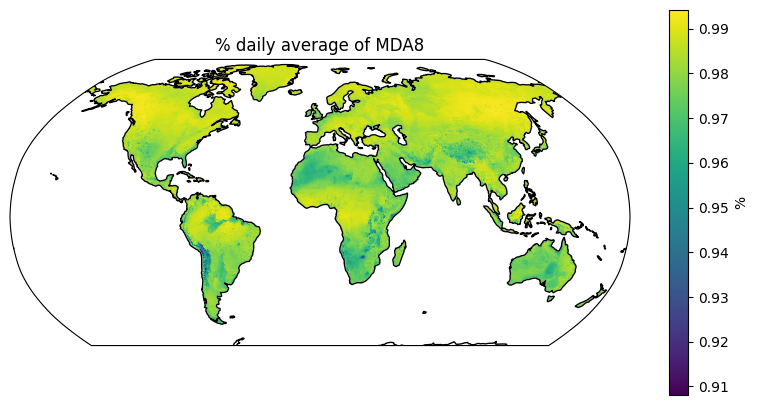

In [10]:
fig, ax = plt.subplots(1,1, figsize=(10, 5), subplot_kw={'projection': ccrs.Robinson()})
#ax.set_extent([0, 360, -90, 90])
mda8_v_day.o3.mean("valid_time").plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={"label": "%"})
ax.coastlines(color="black", zorder=3)
ax.add_feature(cfeature.OCEAN, color="white", zorder=2)
plt.title("% daily average of MDA8")

In [11]:
import numpy as np
mda8_v_day_t_avg = mda8_v_day.groupby("valid_time.month").mean("valid_time")
weights = np.cos(np.deg2rad(mda8_v_day_t_avg.latitude))
range_weighted = mda8_v_day_t_avg.weighted(weights)
weighted_mean = range_weighted.mean(("longitude", "latitude")).load()

In [12]:
weighted_mean.month.values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [13]:
weighted_mean.o3.values.flatten()

array([0.96881079, 0.97658647, 0.96940431, 0.96820768, 0.97083351,
       0.97098348, 0.97307495, 0.97099782, 0.9704434 , 0.96650672,
       0.97065318, 0.96532855])

In [14]:
# check the range here

(0.5, 1.0)

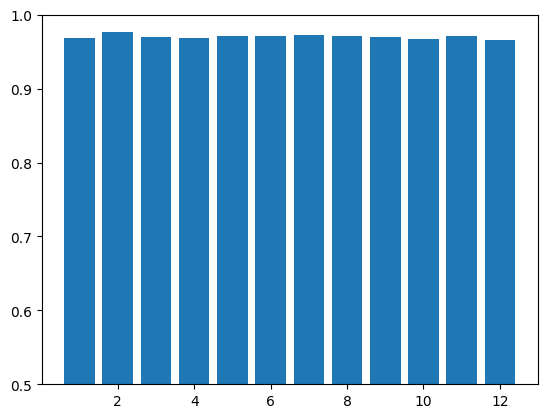

In [17]:
plt.bar(weighted_mean.month, weighted_mean.o3.values.flatten())
plt.ylim(0.5, 1)

In [19]:
mda8_v_day = mda8_v_day.load()

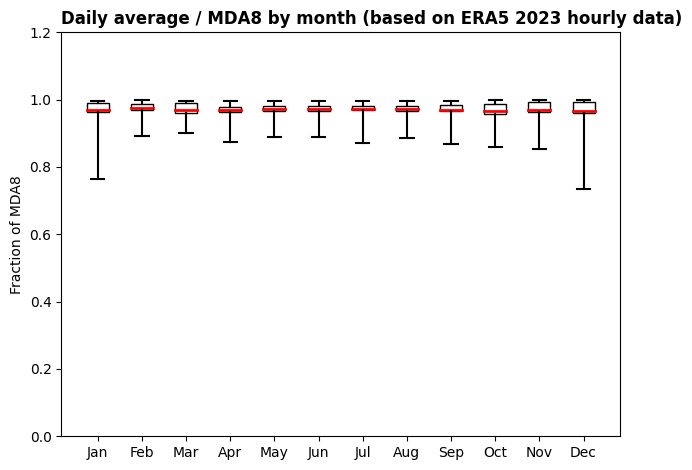

In [39]:
from matplotlib.patches import Rectangle

da = mda8_v_day.to_array().squeeze()  # assumes one variable

monthly = da.groupby("valid_time.month").mean()
stacked = monthly.stack(z=("latitude","longitude"))

w = np.cos(np.deg2rad(monthly.latitude))
wmean = monthly.weighted(w).mean(("latitude","longitude"))

fig, ax = plt.subplots()

cap = 0.15   # half-width of whisker cap
boxw = 0.25  # half-width of box

for m in range(1, 13):
    v = stacked.sel(month=m).dropna("z")

    q25 = v.quantile(0.25).item()
    q75 = v.quantile(0.75).item()
    mean = wmean.sel(month=m).item()

    vmin = v.min().item()
    vmax = v.max().item()

    # box (IQR)
    ax.add_patch(Rectangle((m-boxw, q25), 2*boxw, q75-q25, fill=False))

    # weighted mean (center line)
    ax.plot([m-boxw, m+boxw], [mean, mean], 'r-', lw=2)

    # whiskers
    ax.plot([m, m], [vmin, q25], 'k-')
    ax.plot([m, m], [q75, vmax], 'k-')

    # whisker caps (horizontal lines)
    ax.plot([m-cap, m+cap], [vmin, vmin], 'k-')
    ax.plot([m-cap, m+cap], [vmax, vmax], 'k-')

ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Daily average / MDA8 by month (based on ERA5 2023 hourly data)", loc="left", weight="bold")
ax.set_ylim(0, 1.2)
ax.set_ylabel("Fraction of MDA8")
plt.tight_layout()
plt.show()

# take this, then regrid to 0.1 degree. get the monthly average scale factor, scale the 0.1 data using that - spatially dependent. 

## Get the monthly scale factor and see how much it varies spatially

## or just use the 8 hour value

# Prob just go with the AQG level. singular right

In [43]:
mda8_v_day.groupby("valid_time.month").mean().to_netcdf("mda8_daily_scalefactor/mda8_daily_scalefac_jan-dec_era5_2023.nc")